# 두 데이터셋 실호출 결과

**HF: 632개 중 32개 대분류에서 층화 선택한 94개 / Mercari: 실제 판매글 30개 전체.** 저장된 결과만 분석하며 이 노트북 재실행은 유료 API를 호출하지 않습니다.

- Jev 1.13과 GPT-6 Luna low가 동일한 전체 HS2022 taxonomy를 이용해 greedy 2→4→6 경로를 선택합니다. 정답으로 후보를 줄이지 않습니다. 웹 검색/선례 조회/HS 해설서/이미지 분석/복수 경로 탐색은 하지 않았습니다.
- 두 공급사는 같은 상품에서 동시 실행하고 각 공급사의 단계는 순차 실행합니다. 시간은 각 단계의 실제 HTTP+파싱+검증 시간 합입니다. 큐 대기, 로컬 캐시 재표시, 보고서 생성 시간은 제외합니다.
- HF 정확도는 94개 전체를 분모로 합니다. 보류·실패·누락은 정답으로 세지 않습니다. 전문가 벤치마크 라벨과의 일치이며 한국 HSK 확정이나 법적 분류 검증이 아닙니다.
- Mercari에는 공식 정답이 없습니다. GPT-6 Sol low가 모델 예측·공급사 이름을 보지 않고 독립적으로 같은 계층 분류를 수행했습니다. 그 결과와의 **심사자 일치율**을 계산합니다. OpenAI 모델군의 공유 편향이 있을 수 있으며 정답 정확도로 표시하지 않습니다.
- 비용은 API usage와 공급사 단가를 이용한 추정입니다. 실패 응답도 usage가 있으면 포함하고 심사자 비용을 분리합니다. 청구서 금액은 확인하지 않았습니다.
- 초기 확률 합계 .99가 float 오차로 탈락한 검증 코드 문제를 수정했습니다. 허용범위 1±.01은 유지하며 1e-9 계산 오차만 허용합니다. 저장된 응답을 로컬 재검증했고 같은 요청을 재전송하거나 비용을 중복 집계하지 않았습니다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display,Markdown
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/customs/data/hs2022.json').exists())
(ROOT/'private/jev-experiments/two-datasets-2026-10-06').mkdir(parents=True,exist_ok=True)
report=json.loads((ROOT/'notebooks/two-datasets-results-2026-10-06.json').read_text())
performance=[]
for dataset,providers in report['summary'].items():
    for provider,s in providers.items():
        performance.append({'dataset':dataset,'provider':provider,'model':s['model'],'cases':s['cases'],
            'leaf_answers':s['leaf_answers'],'abstentions':s['abstentions'],'errors':s['workflow_errors'],
            'actual_api_calls':s['actual_api_calls'],'input_tokens':s['input_tokens'],'output_tokens':s['output_tokens'],
            'estimated_cost_usd':s['known_estimated_cost_usd'],'p50_seconds':s['workflow_p50_ms']/1000 if s['workflow_p50_ms'] is not None else None,
            'p95_seconds':s['workflow_p95_ms']/1000 if s['workflow_p95_ms'] is not None else None,
            'latency_n':s['latency_denominator'],'saved_validation_recoveries':s['saved_validation_recoveries']})
performance=pd.DataFrame(performance)
display(performance.round({'estimated_cost_usd':6,'p50_seconds':3,'p95_seconds':3}))
print('Total usage-based cost estimate USD:',performance.estimated_cost_usd.sum())

,dataset,provider,model,cases,leaf_answers,abstentions,errors,actual_api_calls,input_tokens,output_tokens,estimated_cost_usd,p50_seconds,p95_seconds,latency_n,saved_validation_recoveries
0,hscodecomp,jev,jev-1.13.0,94,81,13,0,275,558238,112024,0.023446,0.675,0.848,94,1
1,hscodecomp,llm,gpt-6-luna,94,65,29,0,261,394622,13961,0.054494,4.296,6.288,94,0
2,mercari,jev,jev-1.13.0,30,29,1,0,90,171370,33416,0.007198,0.669,0.782,30,0
3,mercari,llm,gpt-6-luna,30,20,10,0,87,117769,3038,0.015602,3.792,6.116,30,0
4,judge,llm,gpt-6-sol,30,25,5,0,89,118820,2500,0.308996,5.060,7.433,30,0


Total usage-based cost estimate USD: 0.409735986


## HF: 전문가 참조 라벨 기준 정확도

전체 94개 정확도와 답변한 사례의 정확도/coverage를 함께 봅니다. 정답과 일치한 최종 HS6 수가 주 지표입니다. 32개 분류에서 최대 3개씩 선택했으므로 원본 데이터의 품목 비중과 다릅니다. 단계별 경로 정확도는 부분 경로도 포함해 계산하며 HS6 결과에서 단순 절단한 지표와 구분합니다.

In [2]:
quality=[]
for provider,s in report['summary']['hscodecomp'].items():
    q=s['quality']
    quality.append({'provider':provider,'reference_cases':q['reference_cases'],'correct_hs6':q['correct_hs6'],
        'accuracy_all':q['accuracy_all'],'accuracy_answered':q['accuracy_answered'],'coverage':q['coverage'],
        'chapter_path_accuracy_all':q['chapter_path_accuracy_all'],'heading_path_accuracy_all':q['heading_path_accuracy_all']})
quality=pd.DataFrame(quality)
display(quality.style.format({c:'{:.1%}' for c in ['accuracy_all','accuracy_answered','coverage','chapter_path_accuracy_all','heading_path_accuracy_all']}))
hf=pd.DataFrame(report['results']['hscodecomp'])
display(hf.groupby(['top_category','provider']).correct.agg(cases='size',correct='sum').reset_index())
# Preserve failed/abstained rows; bounded preview, full rows remain in JSON.
display(hf[~hf.correct][['id','top_category','provider','reference_hs6','hs6','status','error']].head(30))

,provider,reference_cases,correct_hs6,accuracy_all,accuracy_answered,coverage,chapter_path_accuracy_all,heading_path_accuracy_all
0,jev,94,28,29.8%,34.6%,86.2%,71.3%,45.7%
1,llm,94,36,38.3%,55.4%,69.1%,72.3%,52.1%


,top_category,provider,cases,correct
0,Apparel Accessories,jev,3,2
1,Apparel Accessories,llm,3,2
2,"Automobiles, Parts & Accessories",jev,3,0
3,"Automobiles, Parts & Accessories",llm,3,0
4,Beauty & Health,jev,3,0
...,...,...,...,...
59,Watches,llm,3,2
60,Weddings & Events,jev,3,2
61,Weddings & Events,llm,3,2
62,Women's Clothing,jev,3,1


,id,top_category,provider,reference_hs6,hs6,status,error
0,hscodecomp-0014,Jewelry & Accessories,llm,711790,711719,candidate,None
1,hscodecomp-0014,Jewelry & Accessories,jev,711790,711719,candidate,None
3,hscodecomp-0024,Consumer Electronics,jev,850440,NaN,needs_information,None
4,hscodecomp-0028,Electronic Components & Supplies,jev,850490,850440,candidate,None
5,hscodecomp-0028,Electronic Components & Supplies,llm,850490,850440,candidate,None
6,hscodecomp-0045,Lights & Lighting,llm,854370,851762,candidate,None
7,hscodecomp-0045,Lights & Lighting,jev,854370,853710,candidate,None
8,hscodecomp-0046,Phones & Telecommunications,llm,851779,NaN,needs_information,None
9,hscodecomp-0046,Phones & Telecommunications,jev,851779,852492,candidate,None
12,hscodecomp-0051,Electronic Components & Supplies,llm,854231,854239,candidate,None


## Mercari: 독립 상위 모델 심사자와의 일치

HS6 일치율의 분모는 심사자가 HS6를 선택한 사례입니다. 심사자가 정보 부족/잘못된 후보 경로로 보류한 경우는 따로 표시합니다. 전체 판단 일치율에는 HS6와 보류 상태 일치를 포함합니다. 심사자 호출 실패는 분모에서 제외하고 별도로 보고합니다.

In [3]:
proxy=pd.DataFrame([{'provider':p,**v} for p,v in report['judge_proxy'].items()])
display(proxy.drop(columns=['label_basis']))
mercari=pd.DataFrame(report['results']['mercari'])
display(mercari[['id','provider','hs6','status','judge_hs6','judge_status','judge_agreement']])
print('Judge model:',report['summary']['judge']['llm']['model'])
print('Judge errors:',report['summary']['judge']['llm']['workflow_errors'])
print('Judge cost estimate USD:',report['summary']['judge']['llm']['known_estimated_cost_usd'])

,provider,judge_valid_cases,judge_decision_agreement,judge_decision_agreement_rate,judge_hs6_reference_cases,hs6_matching_judge,hs6_judge_agreement_rate,judge_abstention_cases,abstention_agreements
0,jev,30,21,0.700000,25,21,0.84,5,0
1,llm,30,23,0.766667,25,19,0.76,5,4


,id,provider,hs6,status,judge_hs6,judge_status,judge_agreement
0,mercari-m11463250411,llm,940490,candidate,940490,candidate,True
1,mercari-m11463250411,jev,940490,candidate,940490,candidate,True
2,mercari-m20898018995,llm,NaN,needs_information,NaN,needs_information,True
3,mercari-m20898018995,jev,442019,candidate,NaN,needs_information,False
4,mercari-m22447055992,jev,950300,candidate,950300,candidate,True
5,mercari-m22447055992,llm,950300,candidate,950300,candidate,True
6,mercari-m34023423742,llm,330300,candidate,330300,candidate,True
7,mercari-m34023423742,jev,330300,candidate,330300,candidate,True
8,mercari-m35107808579,llm,851830,candidate,NaN,none_of_above,False
9,mercari-m35107808579,jev,851830,candidate,NaN,none_of_above,False


Judge model: gpt-6-sol
Judge errors: 0
Judge cost estimate USD: 0.308996


## 비용·시간 비교

단계 수와 조기 보류가 비용/시간에 영향을 줍니다. 더 싼 결과가 같은 품질이나 같은 답변률을 뜻하지 않습니다. 심사자 비용은 아래 비교 그래프에서 제외하고 위 표에 별도 표시합니다.

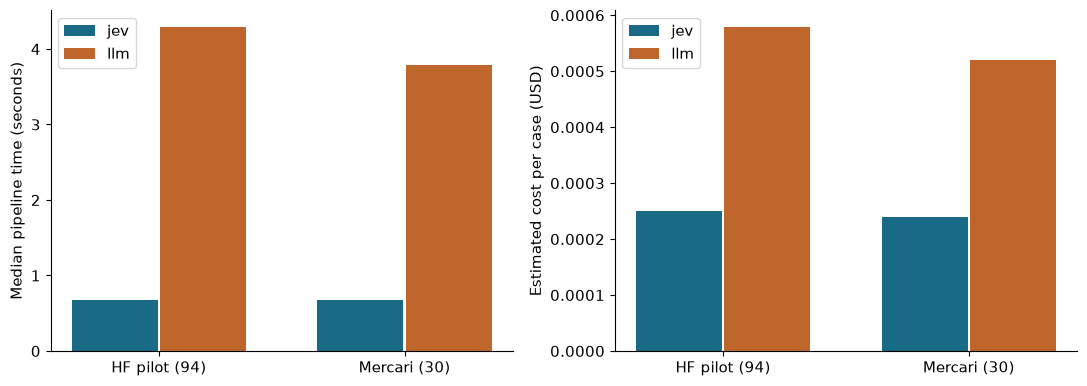

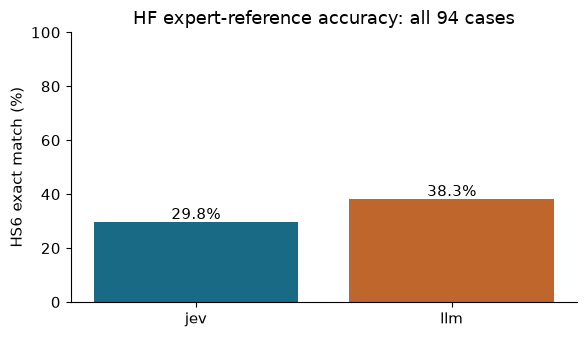

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
fig,axes=plt.subplots(1,2,figsize=(11,4))
x=[0,1];names=['HF pilot (94)','Mercari (30)'];colors={'jev':'#186A85','llm':'#BE662B'}
for provider,offset in [('jev',-.18),('llm',.18)]:
    rows=performance[performance.provider.eq(provider)&performance.dataset.isin(['hscodecomp','mercari'])].set_index('dataset').reindex(['hscodecomp','mercari'])
    axes[0].bar([i+offset for i in x],rows.p50_seconds,width=.35,color=colors[provider],label=provider)
    axes[1].bar([i+offset for i in x],rows.estimated_cost_usd/rows.cases,width=.35,color=colors[provider],label=provider)
axes[0].set_ylabel('Median pipeline time (seconds)')
axes[1].set_ylabel('Estimated cost per case (USD)')
for ax in axes:
    ax.set_xticks(x,names);ax.set_ylim(bottom=0);ax.legend()
fig.tight_layout()
fig.savefig(ROOT/'private/jev-experiments/two-datasets-2026-10-06/cost-time.png',dpi=170)
plt.show()
fig,ax=plt.subplots(figsize=(6,3.5))
ax.bar(quality.provider,quality.accuracy_all*100,color=[colors[p] for p in quality.provider])
ax.set_ylim(0,100);ax.set_ylabel('HS6 exact match (%)');ax.set_title('HF expert-reference accuracy: all 94 cases')
for i,v in enumerate(quality.accuracy_all*100):ax.text(i,v+1,f'{v:.1f}%',ha='center')
fig.tight_layout();plt.show()

## 해석의 범위

현재 계층 탐색은 top-1 경로만 유지합니다. 상위 단계의 오분류나 불필요한 보류가 최종 정확도를 제한할 수 있습니다. 제품 입력이 불충분한 사례도 벤치마크 정답과 다르면 전체 정확도에서는 오답으로 셉니다. 이 차이를 비용 우위와 함께 해석해야 합니다.

HF 전체 632개 성능이나 한국 HSK 정확도로 일반화하지 않습니다. Mercari의 상위 모델 일치는 심사 모델 기준의 대리 지표이며 사람 검토/공식 결정문을 대체하지 않습니다. 두 데이터셋의 정확도와 일치율을 합산하지 않습니다.